In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import random
import numpy as np
import tensorflow as tf
import pandas as pd

# Data Preparation and preprocessing

In [115]:
# Dataset Settings
dataset_path = 'dataset/rice_leaf_diseases'
img_height, img_width = 150, 150
batch_size = 16
random_seed = 42
np.random.seed(random_seed)
random.seed(random_seed)
tf.random.set_seed(random_seed)

In [ ]:
# Data Preparation
# Create an instance of ImageDataGenerator for training and validation
# Data Augmentation
augmented_train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,        # rotation by 30 degrees
    width_shift_range=0.2,    # horizontal shift
    height_shift_range=0.2,   # vertical shift
    shear_range=0.2,          # shear transformation
    zoom_range=0.2,           #  zoom
    horizontal_flip=True,     # horizontal flip 
    fill_mode='nearest'
)
train_generator = augmented_train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',  # Set as training data
    seed = random_seed,
    shuffle = True
)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
)
validation_generator = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_height, img_width),
    batch_size=24,
    class_mode='categorical',
    subset='validation',  # Set as validation data
    seed = random_seed,
    shuffle = False
)


Found 96 images belonging to 3 classes.
Found 24 images belonging to 3 classes.


# BaseLine Model

- A simple baseline model was implemented by always predicting the majority class (class 0 or any class as all classes population is equal ). 
- This approach does not involve any learning and serves as a reference to evaluate the effectiveness of more complex models. 
- The evaluation was conducted using accuracy, precision, recall, and F1-score metrics.

-----------------

In [120]:
# Baseline Model


y_true = validation_generator.classes
y_pred = np.zeros_like(y_true)

accuracy = accuracy_score(y_true, y_pred)
print("Baseline Accuracy:", accuracy)

print("\nClassification Report For Baseline model :\n")
print(classification_report(y_true, y_pred))


Baseline Accuracy: 0.3333333333333333

Classification Report For Baseline model :

              precision    recall  f1-score   support

           0       0.33      1.00      0.50         8
           1       0.00      0.00      0.00         8
           2       0.00      0.00      0.00         8

    accuracy                           0.33        24
   macro avg       0.11      0.33      0.17        24
weighted avg       0.11      0.33      0.17        24



/media/ola/608411B684118FA0/projects/rice_leaf_disease/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/media/ola/608411B684118FA0/projects/rice_leaf_disease/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/media/ola/608411B684118FA0/projects/rice_leaf_disease/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` paramete

## Conclusion

- The baseline model achieved an accuracy of 33%, but failed to correctly classify any samples from the other classes. 
- Precision, recall, and F1-score for classes 1 and 2 were all zero. 
- This demonstrates that the baseline model is insufficient for the task, and a trained model is required to achieve reliable classification across all categories.

# Base CNN Model

## 1. Building Base Model

In [70]:
# Building the base Model
base_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(train_generator.num_classes, activation='softmax')
])


/media/ola/608411B684118FA0/projects/rice_leaf_disease/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [71]:
# Compile base model
base_model.compile(optimizer=Adam(learning_rate=0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])
base_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,739 (18.42 MB)

 Trainable params: 4,828,739 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [72]:
# Train the model
history_base = base_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 709ms/step - accuracy: 0.2613 - loss: 1.7260 - val_accuracy: 0.3333 - val_loss: 1.1077
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 543ms/step - accuracy: 0.3284 - loss: 1.1101 - val_accuracy: 0.3333 - val_loss: 1.0982
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 552ms/step - accuracy: 0.4092 - loss: 1.0837 - val_accuracy: 0.5833 - val_loss: 1.0237
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 568ms/step - accuracy: 0.4723 - loss: 1.0534 - val_accuracy: 0.6250 - val_loss: 0.9765
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 457ms/step - accuracy: 0.4935 - loss: 0.9774 - val_accuracy: 0.3750 - val_loss: 1.2693
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 653ms/step - accuracy: 0.4554 - loss: 0.9067 - val_accuracy: 0.5417 - val_loss: 1.0332
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 475ms/step - accuracy: 0.4964 - loss: 0.9194 - val_accuracy: 0.3750 - val_loss: 2.3054
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 574ms/step - accuracy: 0.5214 - loss: 0.8844 - val_accuracy: 0.5000 - val_loss:

## 2. Evaluate the model

In [ ]:
# Evaluate the model on the validation set
y_true_classes = validation_generator.classes
y_pred = base_model.predict(validation_generator, verbose=1)
y_pred_classes = y_pred.argmax(axis=1)

class_names = list(validation_generator.class_indices.keys())

print("📋 Classification Report:\n")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 641ms/step
📋 Classification Report:

                       precision    recall  f1-score   support

Bacterial leaf blight       0.80      0.50      0.62         8
           Brown spot       0.36      0.62      0.45         8
            Leaf smut       0.60      0.38      0.46         8

             accuracy                           0.50        24
            macro avg       0.59      0.50      0.51        24
         weighted avg       0.59      0.50      0.51        24



## 3. Visualize the results

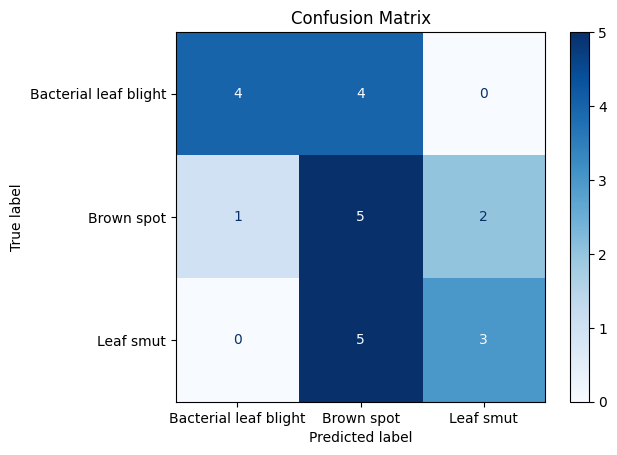

In [74]:
# visualize the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
cm_display.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

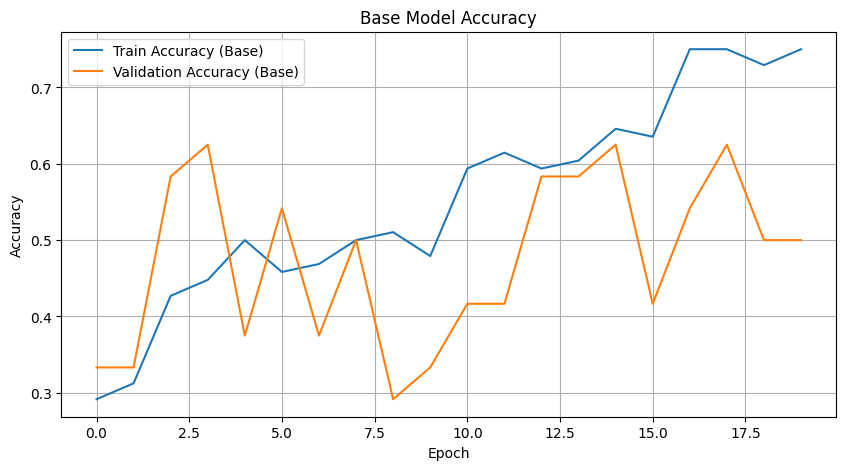

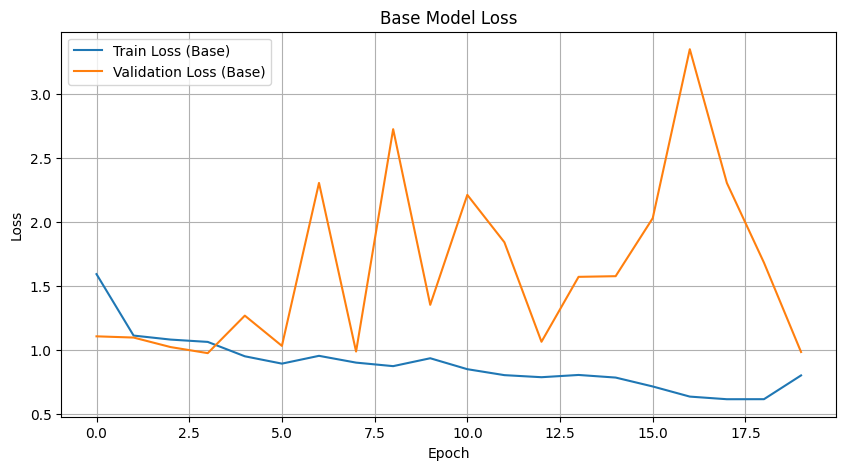

In [75]:
# Plot training & validation accuracy values
# Accuracy graph
plt.figure(figsize=(10,5))
plt.plot(history_base.history['accuracy'], label='Train Accuracy (Base)')
plt.plot(history_base.history['val_accuracy'], label='Validation Accuracy (Base)')
plt.title('Base Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

# Loss graph
plt.figure(figsize=(10,5))
plt.plot(history_base.history['loss'], label='Train Loss (Base)')
plt.plot(history_base.history['val_loss'], label='Validation Loss (Base)')
plt.title('Base Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()


## 4. Save the model

In [77]:
# Save base model 
base_model.save('models/base_model.h5')

## Conclusion
- CNN Model outperforms the baseline model with accuracy 50% and the model learns about the other two classes 
- However, The CNN base model exhibits clear signs of **overfitting**, as indicated by the following behaviors:
1. Accuracy Gap:

    The validation accuracy is significantly lower than the training accuracy, further confirming that the model performs well on training data but fails to generalize to unseen data.

2. Validation Loss Trend:

    The validation loss initially decreases but then stabilizes or starts increasing after a certain point, while the training loss continues to decline. This divergence suggests the model is memorizing training data noise rather than generalizing.

--------

# Fine-tuned Model

## 1. Fine-tune Base Model

In [108]:
# Building the base Model
fine_tuned_model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(train_generator.num_classes, activation='softmax')
])


/media/ola/608411B684118FA0/projects/rice_leaf_disease/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [109]:
# Compile base model
fine_tuned_model.compile(optimizer=Adam(learning_rate=0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])
fine_tuned_model.summary()
# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_62 (Conv2D)              │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_62 (MaxPooling2D) │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_63 (MaxPooling2D) │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_64 (MaxPooling2D) │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 128)            │     2,367,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,391,587 (9.12 MB)

 Trainable params: 2,391,587 (9.12 MB)

 Non-trainable params: 0 (0.00 B)

In [110]:
# Train the model
history_base = fine_tuned_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 722ms/step - accuracy: 0.3490 - loss: 1.4871 - val_accuracy: 0.3333 - val_loss: 1.1365
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 571ms/step - accuracy: 0.3220 - loss: 1.0828 - val_accuracy: 0.2917 - val_loss: 1.1589
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 603ms/step - accuracy: 0.3714 - loss: 1.0450 - val_accuracy: 0.3750 - val_loss: 1.1690
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 585ms/step - accuracy: 0.5171 - loss: 0.9898 - val_accuracy: 0.2083 - val_loss: 1.2920
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 610ms/step - accuracy: 0.4573 - loss: 0.9713 - val_accuracy: 0.5417 - val_loss: 1.1002
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 554ms/step - accuracy: 0.3921 - loss: 1.0996 - val_accuracy: 0.5417 - val_loss: 1.0072
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 561ms/step - accuracy: 0.4994 - loss: 0.9913 - val_accuracy: 0.3333 - val_loss: 1.4467
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 559ms/step - accuracy: 0.4784 - loss: 0.9500 - val_accuracy: 0.4167 - val_loss:

## 2. Evaluate the model


In [ ]:
# Evaluate the model on the validation set

y_true_classes = validation_generator.classes
y_pred = fine_tuned_model.predict(validation_generator, verbose=1)
y_pred_classes = y_pred.argmax(axis=1)

class_names = list(validation_generator.class_indices.keys())

print("📋 Classification Report:\n")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 642ms/step
📋 Classification Report:

                       precision    recall  f1-score   support

Bacterial leaf blight       0.80      1.00      0.89         8
           Brown spot       1.00      0.50      0.67         8
            Leaf smut       0.80      1.00      0.89         8

             accuracy                           0.83        24
            macro avg       0.87      0.83      0.81        24
         weighted avg       0.87      0.83      0.81        24



## 3. Visualize the results

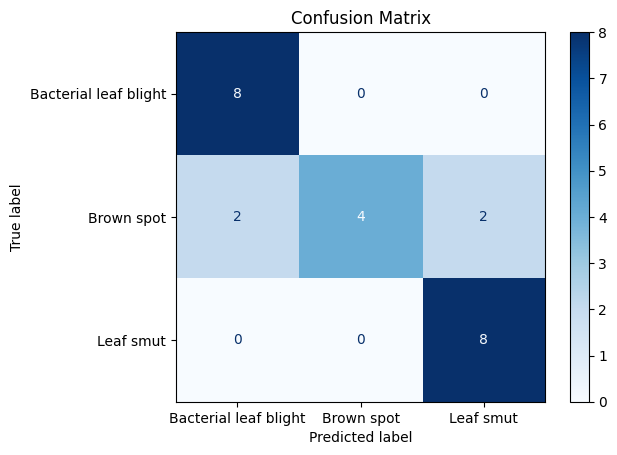

In [112]:
# visualize the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
cm_display.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

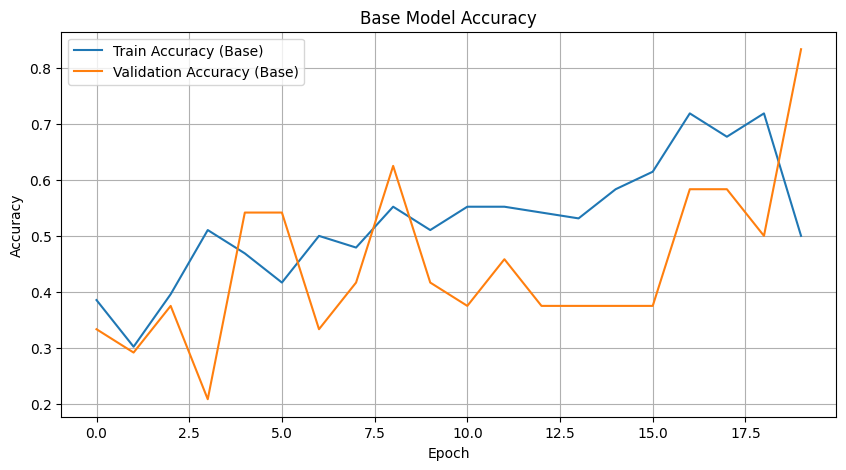

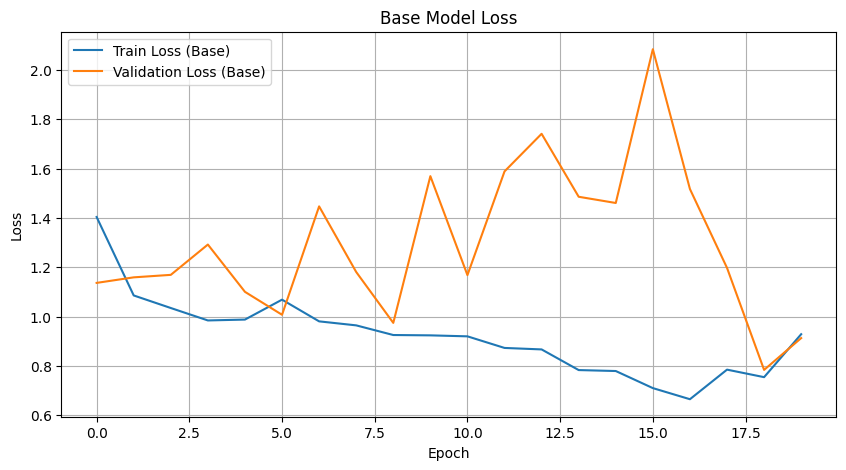

In [113]:
# Plot training & validation accuracy values
# Accuracy graph
plt.figure(figsize=(10,5))
plt.plot(history_base.history['accuracy'], label='Train Accuracy (Base)')
plt.plot(history_base.history['val_accuracy'], label='Validation Accuracy (Base)')
plt.title('Base Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

# Loss graph
plt.figure(figsize=(10,5))
plt.plot(history_base.history['loss'], label='Train Loss (Base)')
plt.plot(history_base.history['val_loss'], label='Validation Loss (Base)')
plt.title('Base Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()


## 4. Save the model

In [114]:
# Save base model 
fine_tuned_model.save('models/fine_tuned_model.h5')

## Conclusion
- To fine-tune Base CNN model and try to solve **Overfitting** problem, we implement two approaches:
    1. In model architecture, update Convolution parameter by decreasing filters number in each convolution layer and add Dropout layer to drop 20% of neurons.
    2. Add EarlyStopping approach while training process to stop training when loss continue increasing .

- The fine-tuned CNN model outperforms other models with accuracy 83% and better evaluations in each class.

---------------

# Final Comparison

In [3]:
# Results
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
baseline_scores = [0.33, 0.11, 0.33, 0.17]
cnn_scores = [0.83, 0.87, 0.83, 0.81] 

# Comparison table
df = pd.DataFrame({
    'Metric': metrics,
    'Baseline Model': baseline_scores,
    'CNN Model': cnn_scores
})

# Visualization
print(df)


      Metric  Baseline Model  CNN Model
0   Accuracy            0.33       0.83
1  Precision            0.11       0.87
2     Recall            0.33       0.83
3   F1-score            0.17       0.81
